# Stable Diffusion Learning

In [1]:
!pip install diffusers --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 60.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.36.0
    Uninstalling diffusers-0.36.0:
      Successfully uninstalled diffusers-0.36.0


In [2]:
!pip install invisible_watermark transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.7 MB/s eta 0:00:00a 0:00:01


In [ ]:
from diffusers import DiffusionPipeline
import torch
import os

pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, use_safetensors=True, variant="fp16")
pipe.to("cuda")

# if using torch < 2.0
# pipe.enable_xformers_memory_efficient_attention()

prompt = "An astronaut riding a green horse"

images = pipe(prompt=prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

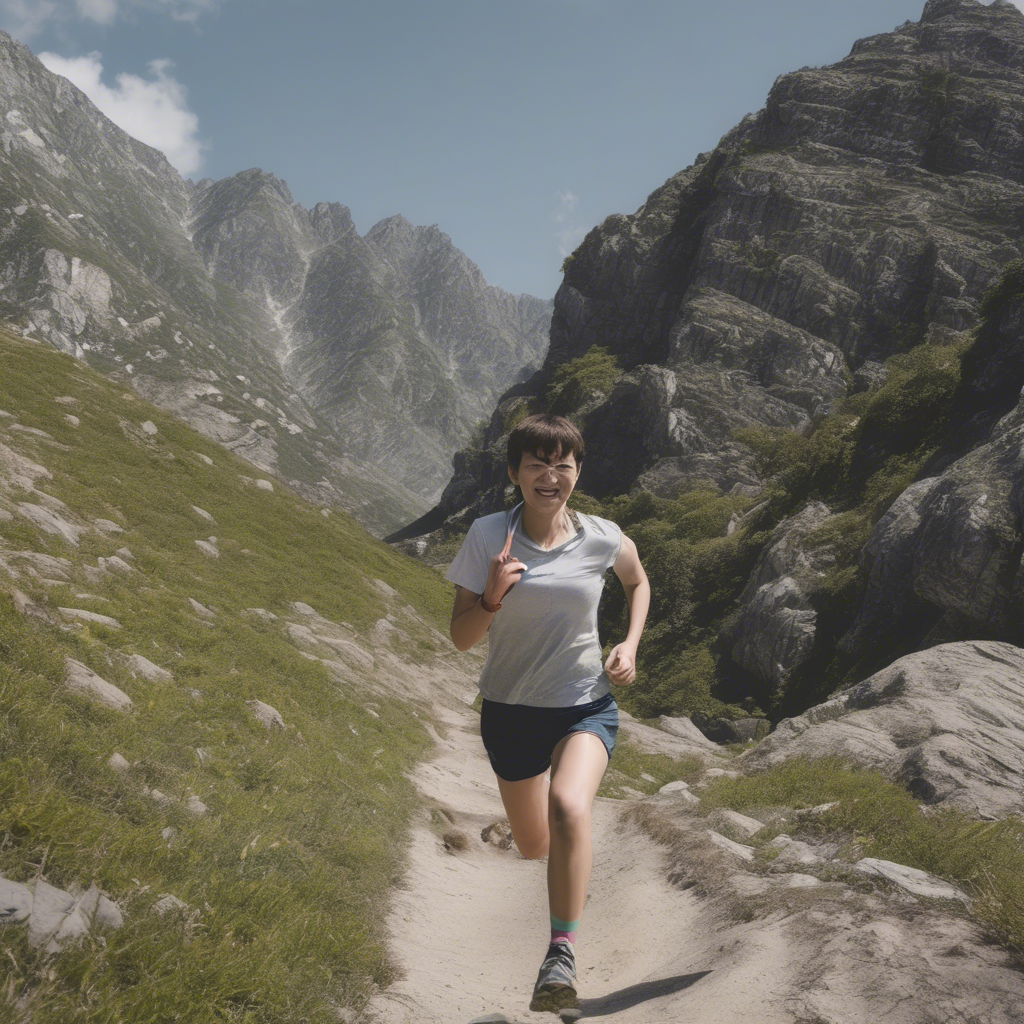

In [5]:
prompt = "Yelan running on mountain"

images = pipe(prompt=prompt).images[0]
images

In [6]:
!pip install gradio

In [8]:
import gradio as gr
from diffusers import StableDiffusionXLPipeline, EulerDiscreteScheduler
import torch

# SDXL Base 1.0 requires StableDiffusionXLPipeline
model_id = "stabilityai/stable-diffusion-xl-base-1.0"

# Load the correct pipeline with memory-efficient settings
pipe = StableDiffusionXLPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
    variant="fp16", 
    use_safetensors=True
)
pipe = pipe.to("cuda")

def generated_image(prompt):
    # SDXL works best with 1024x1024 resolution
    image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
    return image

gr.Interface(
    fn=generated_image,
    inputs=gr.Textbox(label="Enter your prompt"),
    outputs=gr.Image(type="pil"),
    title="SDXL 1.0 - PRAKASH SENAPATI IMAGE GENERATOR APP",
    description="Enter text prompt and see the generated image"
).launch()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://255bab528cd025a4bf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


In [9]:
import torch
from diffusers import DiffusionPipeline
import gradio as gr

# Load Stable Diffusion XL model
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16"
)

pipe.to("cuda")

# Image generation function
def generate_image(prompt):
    image = pipe(prompt=prompt).images[0]
    return image

# Gradio Interface
demo = gr.Interface(
    fn=generate_image,
    inputs=gr.Textbox(label="Enter your prompt"),
    outputs=gr.Image(label="Generated Image"),
    title="Stable Diffusion XL Image Generator",
    description="Generate AI images using Stable Diffusion XL"
)

demo.launch()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

* Running on local URL:  http://127.0.0.1:7862
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://e4aad573e6691e2100.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
import torch
import soundfile as sf
from diffusers import StableAudioPipeline

pipe = StableAudioPipeline.from_pretrained("stabilityai/stable-audio-open-1.0", torch_dtype=torch.float16)
pipe = pipe.to("cuda")

# define the prompts
prompt = "riding on highway with yamaha r1"
negative_prompt = "Low quality."

# set the seed for generator
generator = torch.Generator("cuda").manual_seed(0)

# run the generation
audio = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=200,
    audio_end_in_s=10.0,
    num_waveforms_per_prompt=3,
    generator=generator,
).audios

output = audio[0].T.float().cpu().numpy()
sf.write("hammer.wav", output, pipe.vae.sampling_rate)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GatedRepoError: 401 Client Error. (Request ID: Root=1-69afa46b-3526c85b30fc0357048d283b;7d56fea8-1d2f-4d7b-b6ac-4172efd1c192)

Cannot access gated repo for url https://huggingface.co/stabilityai/stable-audio-open-1.0/resolve/main/model_index.json.
Access to model stabilityai/stable-audio-open-1.0 is restricted. You must have access to it and be authenticated to access it. Please log in.

In [8]:
try:
    import torchsde
    print("Success: torchsde is installed and visible!")
except ImportError:
    print("Error: torchsde is still not found in this environment.")


Success: torchsde is installed and visible!


In [7]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install("torchsde")


In [5]:
!pip install --upgrade diffusers transformers accelerate torchsde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 49.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 107.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 28.4 MB/s eta 0:00:00
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.36.0
    Uninstalling diffusers-0.36.0:
      Successfully uninstalled diffusers-0.36.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.2.0
    Uninstalling transformers-5.2.0:
      Successfully uninstalled transformers-5.2.0
